# Logical magic state distillation

In [31]:
%load_ext autoreload
%autoreload 2

import tsim
import numpy as np
from typing import Literal
import matplotlib.pyplot as plt
from tsim.utils.encoder import ColorEncoder5
from utils.binomial_standard_error import binomial_standard_error as stat_err
from time import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In this tutorial, we will simulate a magic state distillation protocol using Tsim. We will simulate the magic state distillation circuit with 85 qubits introduced in [Rodriguez et al. (2025)](https://www.nature.com/articles/s41586-025-09367-3). This showcases Tsim's ability to simulate large non-Clifford circuits that would be impossible to simulate using a state vector simulator.

### The Geometry of Magic States

To achieve universal fault-tolerant quantum computing, you need a "magic state" that allows you to execute non-Clifford gates. The most robust magic states are the ones that are geometrically the absolute furthest away from the "Clifford octahedron" (the set of easy-to-simulate states on the Bloch sphere).

There are two primary types of magic states:
1. T-type Magic States: These sit exactly halfway between two axes. Their coordinates on the $(X, Y, Z)$ Bloch sphere are $(1/\sqrt{2}, 1/\sqrt{2}, 0)$.
2. H-type Magic States: These point perfectly into the corner of the first octant of the Bloch sphere, sitting exactly equidistant from all three axes. Their coordinates are $(1/\sqrt{3}, 1/\sqrt{3}, 1/\sqrt{3})$.

If you calculate the angle between the Z-axis (the $|0\rangle$ state) and that $(1/\sqrt{3}, 1/\sqrt{3}, 1/\sqrt{3})$ coordinate, the trigonometry yields exactly $\arccos(1/\sqrt{3})$, which is $0.9553$ radians, or $0.3041\pi$.

The code below uses a two-step rotation to navigate from the $|0\rangle$ pole exactly to that $H$-type magic state coordinate.
1. R_X(-0.3041*pi): This rotates the state away from the Z-axis (the north pole) downwards along the Y-Z plane by exactly $\arccos(1/\sqrt{3})$.
2. T_DAG: This applies a $-45^\circ$ ($-\pi/4$) phase rotation around the Z-axis.If you trace this mathematically, the combination of these two rotations creates this exact superposition:$$\cos(\theta/2)|0\rangle + e^{i\pi/4}\sin(\theta/2)|1\rangle$$
   (where $\theta = \arccos(1/\sqrt{3})$).

When you compute the expectation values $\langle X \rangle$, $\langle Y \rangle$, and $\langle Z \rangle$ for this superposition, they all perfectly evaluate to $1/\sqrt{3}$.

#### Why the 5-to-1 Protocol Needs It?

The distillation engine in your circuit (the dense block of CZ and SQRT_X gates) is a hard-coded 5-to-1 protocol that is mathematically optimized specifically for H-type magic states.

If you fed this specific distillation block standard T-type magic states, the error-canceling symmetries would fail, and the noise would not be properly funneled onto the ancilla qubits. You must prepare the raw input states using this exact 0.3041*pi angle for the 5-to-1 filter to successfully distill them.

### Magic states

If you apply a non-Clifford $X$-rotation, and then immediately follow it with a non-Clifford $Z$-rotation ($T^\dagger$), they combine into one single, slightly diagonal rotation.

You are not stacking "two magics" on top of each other; you are just giving the simulator a two-step driving direction to reach one highly specific destination coordinate on the Bloch sphere (the $H$-type magic state).

We start by preparing a particular magic state, the eigenstate of the "SH" operator. To simulate noise, we add a depolarizing channel after state preparation:

In [32]:
theta = -np.arccos(np.sqrt(1 / 3)) / np.pi  # Distillation angle

c = tsim.Circuit(f"R 0 \n R_X({theta}) 0 \n T_DAG 0 \n DEPOLARIZE1(0.05) 0 \n")
c.diagram("timeline-svg", height=100)

By undoing the state preparation at the end, we can measure the infidelity:

In [33]:
p = 0.05
c = tsim.Circuit(f"""
    R 0 
    R_X({theta}) 0
    T_DAG 0
    DEPOLARIZE1({p}) 0
    T 0
    R_X({-theta}) 0
    M 0
    """)
sampler = c.compile_sampler()
samples = sampler.sample(100_000, batch_size=100_000)
print(f"Infidelity: {np.count_nonzero(samples) / len(samples)}")
c.diagram("timeline-svg", height=100)

Task was destroyed but it is pending!
task: <Task pending name='Task-161' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-162' coro=<Kernel.shell_main() running at /opt/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/venv/lib/python3.12/site-packages/pyzx_param/graph/graph_s.py:39: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self._qindex: Dict[int, FloatInt]               = dict()
Task was destroyed but it is pending!
task: <Task pending name='Task-162' coro=<Kernel.shell_main() running at /opt/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Infidelity: 0.03355


The noisy state preparation process produces a magic state with 97% fidelity.

### Magic state distillation: The ideal case

Given multiple noisy magic states of low fidelity, we can distill a single high-fidelity magic state using a distillation circuit:

In [34]:
def make_logical_distillation_circuit(angle: float):
    return tsim.Circuit(f"""
        # initial state
        R 0 1 2 3 4
        R_X({angle}) 0 1 2 3 4
        T_DAG 0 1 2 3 4
        DEPOLARIZE1({p}) 0 1 2 3 4


        # distillation
        SQRT_X 0 1 4
        CZ 0 1 2 3
        SQRT_Y 0 3
        CZ 0 2 3 4
        TICK
        SQRT_X_DAG 0
        CZ 0 4 1 3
        TICK
        SQRT_X_DAG 0 1 2 3 4

        # undo
        T 0
        R_X({-angle}) 0

        M 0 1 2 3 4
        """)


c = make_logical_distillation_circuit(theta)
c.diagram("timeline-svg", height=240)

In this distillation circuit, qubits [q1, q2, q3, q4] are the distillation syndrome. 
If we measure them in the state [1,0,1,1], we know that distillation was successful and the first qubit q0 is in a magic state with higher fidelity.

We can simulate this using Tsim. To measure the fidelity, we undo the magic state preparation on the first qubit and perform a measurement in the Z basis.

In [35]:
sampler = c.compile_sampler(seed=0)
samples = sampler.sample(50_000, batch_size=10_000)


def post_select(samples: np.ndarray):
    distilled_output = samples[:, 0]
    distillation_syndromes = samples[:, 1:]
    sel = np.all(distillation_syndromes == np.array([1, 0, 1, 1]), axis=1)
    return distilled_output[sel]


post_selected_samples = post_select(samples)
print(
    f"Infidelity: {np.count_nonzero(post_selected_samples) / len(post_selected_samples):.5f}"
)
print(
    f"Percentage of post-selected samples: {len(post_selected_samples) / len(samples) * 100:.2f}%"
)

Infidelity: 0.00658
Percentage of post-selected samples: 14.29%


After distillation, the fidelity has increased to 99.3%. This is much better than the original 97% of the individual input magic states. A downside is that the distillation process is only successful 14% of the time. This means we have to repeat the distillation process multiple times until we get a good output state.

#### The "Perfect T-state" Caveat

There are two slight corrections to your assumption about Qubit 0:
1. It is an H-state, not a T-state: As established earlier, the $0.3041\pi$ angle prepares an H-type magic state. While it serves the exact same purpose as a T-state (enabling universal quantum computing), it is technically a different coordinate on the Bloch sphere.
2. It is distilled, but not strictly "perfect": The 5-to-1 distillation protocol heavily suppresses physical errors, but it does not eliminate them entirely. If your incoming raw states have an error rate of $p$, a successful 0000 distillation usually outputs a state with an error rate proportional to $p^2$. If you need it to be closer to "perfect" for a massive algorithm, you take five of these distilled Qubit 0s and run them through the 5-to-1 filter a second time (Level-2 Distillation) to achieve an error rate of $p^4$.

With Tsim, we can study other properties of the distillation circuit. For example, we can analyze the dependence of the fidelity on the rotation angle of the `R_X` gate:

In [36]:
angles = np.linspace(-0.4, 0.4, 7) + theta
fidelities = []
fidelity_errs = []
post_selection_rate = []
post_selection_errs = []
shots_per_point = 1024 * 5
T0=time()
for angle in angles:
    c = make_logical_distillation_circuit(angle)
    sampler = c.compile_sampler(seed=0)
    samples = sampler.sample(shots_per_point, batch_size=shots_per_point)

    post_selected_samples = post_select(samples)
    n_ps = len(post_selected_samples)
    N_tot = len(samples)
    post_selection_rate.append(n_ps / N_tot)
    post_selection_errs.append(stat_err(n_ps, N_tot))

    n_err = int(np.count_nonzero(post_selected_samples))
    f = n_err / n_ps
    fidelities.append(1 - f)
    fidelity_errs.append(stat_err(n_err, n_ps))
print(f'simu elaT={time()-T0:.1f}sec')

simu elaT=24.2sec


Text(0.5, 1.0, 'Optimial alngle to H-state, using 5120 shots/point')

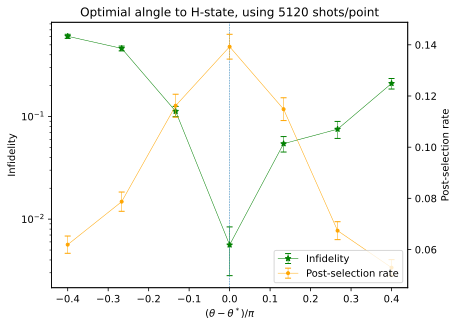

In [37]:
fig, ax1 = plt.subplots()

x = angles - theta
infid = 1 - np.array(fidelities)

line1 = ax1.errorbar(
    x, infid, yerr=fidelity_errs, fmt="*-", c="g", lw=0.5, capsize=3, label="Infidelity"
)
ax1.set_yscale("log")
ax1.axvline(0, linestyle="--", lw=0.5)
ax1.set_xlabel(r"$(\theta - \theta^*)/\pi$")
ax1.set_ylabel("Infidelity")

ax2 = ax1.twinx()
line2 = ax2.errorbar(
    x,
    post_selection_rate,
    yerr=post_selection_errs,
    fmt=".-",
    c="orange",
    lw=0.5,
    capsize=3,
    label="Post-selection rate",
)
ax2.set_ylabel("Post-selection rate")
ax2.legend(handles=[line1, line2], loc="lower right");
ax2.set_title(f'Optimial alngle to H-state, using {shots_per_point} shots/point')

We see that the output fidelity and post-selection rate are peaked at the distillation angle $\theta^*$.

### Magic state distillation: The realistic case (with noise)

On a real quantum computer, the distillation circuit is noisy itself. Here, the benefit of distillation is
generally outweighed by the noise in the distillation circuit.

We can explicitly see this using a simulation, where we add noise to the distillation circuit. Note that we consider two different noise scales:
- `p` is the noise that captures the magic state preparation process.
- `noise` is the strength of the depolarizing noise in the distillation circuit.

In [38]:
noise = p / 5
c = tsim.Circuit(f"""
# initial state
R 0 1 2 3 4
R_X({theta}) 0 1 2 3 4
T_DAG 0 1 2 3 4
DEPOLARIZE1({p}) 0 1 2 3 4


# distillation
DEPOLARIZE1({noise}) 0 1 2 3 4
SQRT_X 0 1 4
DEPOLARIZE1({noise}) 0 1 4
CZ 0 1 2 3
DEPOLARIZE2({noise}) 0 1 2 3
SQRT_Y 0 3
DEPOLARIZE1({noise}) 0 3
CZ 0 2 3 4
DEPOLARIZE2({noise}) 0 2 3 4
TICK
SQRT_X_DAG 0
DEPOLARIZE1({noise}) 0
CZ 0 4 1 3
DEPOLARIZE2({noise}) 0 4 1 3
TICK
SQRT_X_DAG 0 1 2 3 4
DEPOLARIZE1({noise}) 0 1 2 3 4

# undo
T 0
R_X({-theta}) 0

M 0 1 2 3 4
""")

T0=time()
samples = c.compile_sampler(seed=0).sample(shots=40_000, batch_size=10_000)
print(f'simu elaT={time()-T0:.1f}sec')

def post_select(samples: np.ndarray):
    distilled_output = samples[:, 0]
    distillation_syndromes = samples[:, 1:]
    sel = np.all(distillation_syndromes == np.array([1, 0, 1, 1]), axis=1)
    return distilled_output[sel]


post_selected_samples = post_select(samples)
print(
    f"Infidelity: {np.count_nonzero(post_selected_samples) / len(post_selected_samples):.5f}"
)
print(
    f"Percentage of post-selected samples: {len(post_selected_samples) / len(samples) * 100:.2f}%"
)

simu elaT=13.7sec
Infidelity: 0.03775
Percentage of post-selected samples: 12.78%


We see that the addition of noise has reduced the output fidelity to ~96%. This is worse than the input state!

# Encoding the distillation circuit

To address this issue, we need to make our distillation circuit resilient to noise.
We do this by encoding it using a quantum error correction code, specifically the [17,1,5] color code. The helper class `ColorEncoder5` provides a convenient way to encode the distillation circuit. Each qubit will be encoded into 17 physical qubits using an encoding circuit. After that, each gate of the distillation circuit will be applied transversally to the encoded qubits.

In [39]:
def make_circuit(basis: Literal["X", "Y", "Z"], p_prep: float, noise: float = 0):
    encoder = ColorEncoder5()
    encoder.initialize(
        f"""
        R 0 1 2 3 4
        R_X({theta}) 0 1 2 3 4
        T_DAG 0 1 2 3 4
        DEPOLARIZE1({p_prep}) 0 1 2 3 4
        """,
    )
    encoder.encode_transversally(
        f"""
        SQRT_X 0 1 4
        DEPOLARIZE1({noise}) 0 1 4
        CZ 0 1 2 3
        DEPOLARIZE2({noise}) 0 1 2 3
        SQRT_Y 0 3
        DEPOLARIZE1({noise}) 0 3
        CZ 0 2 3 4
        DEPOLARIZE2({noise}) 0 2 3 4
        TICK
        SQRT_X_DAG 0
        DEPOLARIZE1({noise}) 0
        CZ 0 4
        DEPOLARIZE2({noise}) 0 4
        TICK
        CZ 1 3
        DEPOLARIZE2({noise}) 1 3
        TICK
        SQRT_X_DAG 0 1 2 3 4
        DEPOLARIZE1({noise}) 0 1 2 3 4
        """
        + ("H 0" if basis == "X" else "H_YZ 0" if basis == "Y" else "")
        + """
        M 0 1 2 3 4
        DETECTOR rec[-5]
        DETECTOR rec[-4]
        DETECTOR rec[-3]
        DETECTOR rec[-2]
        DETECTOR rec[-1]
        OBSERVABLE_INCLUDE(0) rec[-5]
        OBSERVABLE_INCLUDE(1) rec[-4]
        OBSERVABLE_INCLUDE(2) rec[-3]
        OBSERVABLE_INCLUDE(3) rec[-2]
        OBSERVABLE_INCLUDE(4) rec[-1]
        """
    )
    return encoder.circuit


c = make_circuit("Z", p_prep=p, noise=p / 10)
print(f"""Qubits: {c.num_qubits}
Detectors: {c.num_detectors}
Observables: {c.num_observables}""")
c.diagram("timeline-svg", height=500)

Qubits: 85
Detectors: 40
Observables: 5


## The fully encoded protocol

The full circuit now contains 85 qubits: 5 logical qubits, constructed from 17 physical qubits each.

Let us summarize the protocol we are going to simulate:
- **Prepare 5 encoded magic states at 97% fidelity.** The input magic states are noisy, and we assume the encoding process to be noiseless. While this is a simplification for this tutorial, it does not introduce any qualitative changes. We can think of this as an abstract preparation protocol that produces 5 encoded magic states, each with 97% fidelity.
- **Distill 5 encoded magic states into a single logical qubit.** We use the transversal encoding of the distillation circuit shown above. This includes depolarization noise with strength `noise`.
- **Perform post-selection** We will perform two stages of post-selection: (a) post-select on perfect stabilizers, and (b) post-select on the [1,0,1,1] distillation syndrome of logical bits.
- **Quantum state tomography** We will perform quantum state tomography on the output logical qubit to estimate its magic state fidelity.

In [40]:
def sample_and_post_select(circ: tsim.Circuit, shots: int = 35_000):
    sampler = circ.compile_detector_sampler(seed=42)

    det_samples, obs_samples = sampler.sample(
        shots=shots, batch_size=shots, separate_observables=True
    )

    # post-select on perfect stabilizers
    perfect_stabilizers = np.all(det_samples == 0, axis=1)
    obs_samples = obs_samples[perfect_stabilizers]

    post_selected_observables = post_select(obs_samples)
    p1 = np.count_nonzero(post_selected_observables) / len(post_selected_observables)
    eval = 1 - 2 * p1
    print(
        f"Expectation value: {eval:.4f}, percentage kept: {len(post_selected_observables) / shots * 100:.2f}%"
    )
    return eval

In [41]:
circ_x, circ_y, circ_z = (
    make_circuit("X", p, p / 5),
    make_circuit("Y", p, p / 5),
    make_circuit("Z", p, p / 5),
)
vx = sample_and_post_select(circ_x)
vy = sample_and_post_select(circ_y)
vz = sample_and_post_select(circ_z)

Expectation value: 0.5500, percentage kept: 1.14%
Expectation value: 0.5561, percentage kept: 1.17%
Expectation value: 0.6010, percentage kept: 1.15%


It would be impossible to simulate an 85-qubit circuit using a state vector simulator. But with Tsim, we can compute hundreds of thousands of shots in a few seconds.

Finally, we construct a density matrix from the measured logical expectation values:

In [42]:
id = np.eye(2)
x = np.array([[0, 1], [1, 0]])
y = np.array([[0, -1j], [1j, 0]])
z = np.array([[1, 0], [0, -1]])

rho = (id + vx * x + vy * y + vz * z) / 2

Next, we compute a statevector for the expected magic state:

In [43]:
a = theta * np.pi
rx = np.array(
    [[np.cos(a / 2), -1j * np.sin(a / 2)], [-1j * np.sin(a / 2), np.cos(a / 2)]]
)
t_dag = np.array([[1, 0], [0, np.exp(-1j * np.pi / 4)]])
psi_expected = t_dag @ rx @ np.array([1, 0])

Then, we compute the fidelity as $\langle\psi_{expected}|\rho|\psi_{expected}\rangle$:

In [44]:
fidelity = psi_expected.conj().T @ rho @ psi_expected
print(f"Infidelity: {1 - fidelity.real:.5f}")

Infidelity: 0.00720


We find that the overall fidelity has been increased from 97% of the individual encoded magic states to 99% of the output logical qubit, despite the presence of noise in the distillation circuit. This is an exciting result of quantum error correction!

This concludes our tutorial. We have learned:
- how to model noisy magic states and **simulate fidelities** using Tsim
- how to perform **magic state distillation** and **post-selection**
- how to **encode a distillation circuit** using the [17,1,5] color code
- how to **simulate hundreds of thousands of shots** of this 85-qubit circuit within seconds on a laptop
- how magic state distillation can improve the fidelity of noisy magic states, **even when the distillation circuit is noisy itself**